Mounted at /content/drive


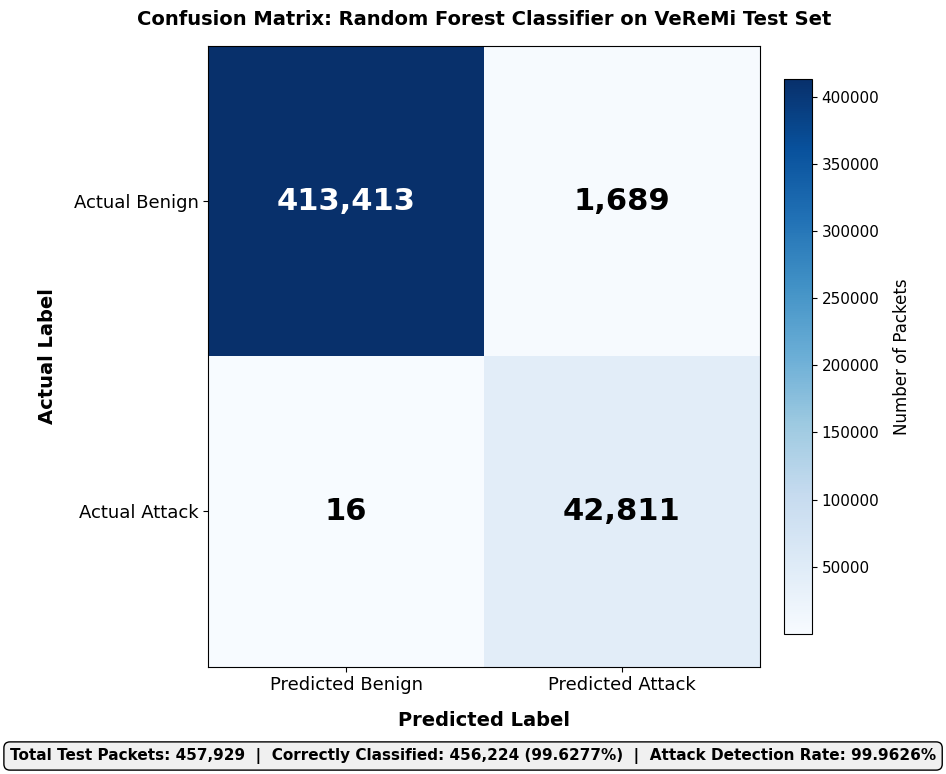

Saved: figure_confusion_matrix_github.png


In [1]:
# ============================================================
# Figure 10: Confusion Matrix for Random Forest Classifier
# GitHub version (with title)
# Uses locked empirical values from results.json
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import numpy as np

# Locked confusion matrix values from results.json
TN = 413413  # True Negatives
FP = 1689    # False Positives
FN = 16      # False Negatives
TP = 42811   # True Positives

# Build confusion matrix
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(9, 7.5))

im = ax.imshow(cm, cmap='Blues', aspect='auto')

threshold = cm.max() / 2
for i in range(2):
    for j in range(2):
        value = cm[i][j]
        text_color = 'white' if value > threshold else 'black'
        ax.text(j, i, f'{value:,}', ha='center', va='center',
                fontsize=22, fontweight='bold', color=text_color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Benign', 'Predicted Attack'], fontsize=13)
ax.set_yticklabels(['Actual Benign', 'Actual Attack'], fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=12)
ax.set_ylabel('Actual Label', fontsize=14, fontweight='bold', labelpad=12)
ax.set_title('Confusion Matrix: Random Forest Classifier on VeReMi Test Set',
             fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of Packets', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=11)

total = cm.sum()
correctly_classified = TN + TP
attack_detection_rate = TP / (TP + FN) * 100
fig.text(0.5, -0.02,
         f"Total Test Packets: {total:,}  |  "
         f"Correctly Classified: {correctly_classified:,} ({correctly_classified/total*100:.4f}%)  |  "
         f"Attack Detection Rate: {attack_detection_rate:.4f}%",
         ha="center", fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/veremi_thesis/figure_confusion_matrix_github.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure_confusion_matrix_github.png")